Imports

In [1]:
# !pip install hvplot
# !pip install hiplot
# !pip install jupyter_bokeh

In [2]:
import pandas as pd
import hvplot.pandas
import hiplot as hip

Downloading datasets

In [3]:
df_realestate_price = pd.read_csv('https://www.ksh.hu/stadat_files/lak/hu/lak0055.csv',encoding='latin_1',sep=';',skiprows=1)
df_realestate_sales = pd.read_csv('https://www.ksh.hu/stadat_files/lak/hu/lak0053.csv',encoding='latin_1',sep=';',skiprows=1)
df_net_salary =pd.read_csv('https://www.ksh.hu/stadat_files/mun/hu/mun0176.csv',encoding='latin_1',sep=';',skiprows=1)

In [4]:
# Using English column and value names
# df_realestate_price
df_realestate_price.rename(columns={
    'Régió': 'Region',
    'Épülettípus': 'BuildingType'
}, inplace=True)

df_realestate_price.replace({
    'BuildingType':
    {
        'családi ház, sorház': 'single-family house, row house',
        'többlakásos': 'multi-apartment',
        'lakótelep': 'housing estate',
        'együtt': 'together',
        'összesen': 'total'
    }
}, inplace=True)

# df_realestate_sales
df_realestate_sales.rename(columns={
    'Régió': 'Region',
    'Jogállás': 'LegalStatus'
}, inplace=True)

df_realestate_sales.replace({
    'LegalStatus':
    {
        'fõváros': 'capital city',
        'városok': 'towns',
        'községek': 'villages',
        'együtt': 'together',
        'vármegyeszékhely': 'county seat',
        'összesen': 'total'
    }
}, inplace=True)

# # df_net_salary
df_net_salary.rename(columns={
    'Területi egység neve': 'RegionName',
    'Területi egység szintje': 'RegionLevel'
}, inplace=True)

df_net_salary.replace({
    'RegionLevel':
    {
        'fõváros, régió': 'capital city, region',
        'vármegye, régió': 'county, region',
        'nagyrégió': 'large region',
        'vármegye': 'county',
        'régió': 'region',
        'ország': 'country'
    }
}, inplace=True)

df_net_salary.columns=['RegionName', 'RegionLevel', '2018. I.',
       '2018. II.', '2018. III.', '2018. IV.',
       '2019. I.', '2019. II.', '2019. III.',
       '2019. IV.', '2020. I.', '2020. II.',
       '2020. III.', '2020. IV.', '2021. I.',
       '2021. II.', '2021. III.', '2021. IV.',
       '2022. I.', '2022. II.', '2022. III.',
       '2022. IV.']







Preprocessing functions

In [5]:
def preprocc_for_realestateprices(df):
    for i in df.columns[2:]:
        df[i] = df[i].astype(str).str.strip().str.replace(' ','').str.replace('..','0').astype(float)
    for i in df.columns[:2]:
        df[i] = df[i].astype('string')
    df_new=(pd.melt(df,id_vars=['Region', 'BuildingType'],var_name='Quarter',value_name='PricePerSquareMeter(Thousand HUF)'))
    return df_new

def preprocc_for_realestate_sales(df):
    for i in df.columns[2:]:
        df[i] = df[i].astype(str).str.strip().str.replace(' ','').str.replace('..','0').astype(float)
    for i in df.columns[:2]:
        df[i] = df[i].astype('string')
    df_new=(pd.melt(df,id_vars=['Region', 'LegalStatus'],var_name='Quarter',value_name='NumberOfTransactions'))
    return df_new

def preprocc_for_net_salary(df):
    for i in df.columns[2:]:
        df[i] = df[i].astype(str).str.strip().str.replace(' ','').str.replace('..','0').astype(float)
    for i in df.columns[:2]:
        df[i] = df[i].astype('string')
    df_new=(pd.melt(df,id_vars=['RegionName', 'RegionLevel'],var_name='Quarter',value_name='NetWage(HUF)'))
    return df_new

def prepocess(df):
    #TODO (paramslist can be altered)
    pass


Separate new and secondhand real estates, preprocessing, reshaping and concatenating

In [6]:
#price

df_sechand=pd.DataFrame(df_realestate_price.iloc[1:37])
df_new=pd.DataFrame(df_realestate_price.iloc[38:])
df_sechand_long=preprocc_for_realestateprices(df_sechand)
df_sechand_long['Type']='sechand'
df_new_long=preprocc_for_realestateprices(df_new)
df_new_long['Type']='new'
df_long_re_prices = pd.concat([df_sechand_long,df_new_long],axis=0).reset_index(drop=True)

#sales

df_sechand=pd.DataFrame(df_realestate_sales.iloc[1:34])
df_new=pd.DataFrame(df_realestate_sales.iloc[35:])
df_sechand_long=preprocc_for_realestate_sales(df_sechand)
df_sechand_long['Type']='sechand'
df_new_long=preprocc_for_realestate_sales(df_new)
df_new_long['Type']='new'
df_long_realestate_sales = pd.concat([df_sechand_long,df_new_long],axis=0).reset_index(drop=True)

# net_salary

df_net_salary = pd.DataFrame(df_net_salary.iloc[1:31])
df_net_salary_long = preprocc_for_net_salary(df_net_salary)
df_net_salary_long


,RegionName,RegionLevel,Quarter,NetWage(HUF)
0,Budapest,"capital city, region",2018. I.,265035.0
1,Pest,"county, region",2018. I.,190204.0
2,Közép-Magyarország,large region,2018. I.,248109.0
3,Fejér,county,2018. I.,203007.0
4,Komárom-Esztergom,county,2018. I.,205502.0
...,...,...,...,...
595,Békés,county,2022. IV.,255655.0
596,Csongrád-Csanád,county,2022. IV.,294772.0
597,Dél-Alföld,region,2022. IV.,284195.0
598,Alföld és Észak,large region,2022. IV.,277303.0


In [7]:
df_long_realestate_sales[df_long_realestate_sales['LegalStatus']=='together']

,Region,LegalStatus,Quarter,NumberOfTransactions,Type
3,Pest,together,2021. I.,4060.0,sechand
7,Közép-Dunántúl,together,2021. I.,4342.0,sechand
11,Nyugat-Dunántúl,together,2021. I.,3895.0,sechand
15,Dél-Dunántúl,together,2021. I.,3950.0,sechand
19,Észak-Magyarország,together,2021. I.,4567.0,sechand
...,...,...,...,...,...
1298,Nyugat-Dunántúl,together,2025. IV.,NaN,new
1302,Dél-Dunántúl,together,2025. IV.,NaN,new
1306,Észak-Magyarország,together,2025. IV.,NaN,new
1310,Észak-Alföld,together,2025. IV.,NaN,new


In [8]:
df=df_long_realestate_sales[df_long_realestate_sales['LegalStatus']=='together']

df_new = df[df['Type']=='new']
df_secondhand = df[df['Type']=='sechand']

df_prices = df_new.join(df_secondhand.set_index(['Region','Quarter']),on=['Region','Quarter'],lsuffix='_New',rsuffix='_Sechand').reset_index(drop=True)

df_prices=df_prices.drop(columns=['Type_New','Type_Sechand','LegalStatus_New','LegalStatus_Sechand']) # Drop redundant rows

df_prices['Sechand_transaction/New_Transaction']=df_prices['NumberOfTransactions_Sechand']/df_prices['NumberOfTransactions_New'] # Create new column for ration

df_prices

,Region,Quarter,NumberOfTransactions_New,NumberOfTransactions_Sechand,Sechand_transaction/New_Transaction
0,Pest,2021. I.,759.0,4060.0,5.349144
1,Közép-Dunántúl,2021. I.,215.0,4342.0,20.195349
2,Nyugat-Dunántúl,2021. I.,576.0,3895.0,6.762153
3,Dél-Dunántúl,2021. I.,240.0,3950.0,16.458333
4,Észak-Magyarország,2021. I.,97.0,4567.0,47.082474
...,...,...,...,...,...
135,Nyugat-Dunántúl,2025. IV.,NaN,NaN,NaN
136,Dél-Dunántúl,2025. IV.,NaN,NaN,NaN
137,Észak-Magyarország,2025. IV.,NaN,NaN,NaN
138,Észak-Alföld,2025. IV.,NaN,NaN,NaN


## Part 0 — Data Inspection & Cleaning (Critical!)

It turns out that the `df_realestate_price` dataset has the joined block tables (meaning two tables concatenated together when it's not appropriate). From index `0-36` it's Used House (Használt lakások) and from `36-end` it's New House (Új lakások). Below is showing where these `title` columns are.

In [9]:
df_realestate_price.head(1)

,Region,BuildingType,2021. I.,2021. II.,2021. III.,2021. IV.,2022. I.,2022. II.,2022. III.,2022. IV.,...,2023. III.,2023. IV.,2024. I.,2024. II.,2024. III.,2024. IV.,2025. I.,2025. II.,2025. III.,2025. IV.
0,Használt lakások,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df_realestate_price[df_realestate_price['Region'] == "Új lakások"]

,Region,BuildingType,2021. I.,2021. II.,2021. III.,2021. IV.,2022. I.,2022. II.,2022. III.,2022. IV.,...,2023. III.,2023. IV.,2024. I.,2024. II.,2024. III.,2024. IV.,2025. I.,2025. II.,2025. III.,2025. IV.
37,Új lakások,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Split the dataframe
df_used = pd.DataFrame(df_realestate_price.iloc[1:37]) 
# at 37 the is Uj lakasok
df_new = pd.DataFrame(df_realestate_price.iloc[38:])

# Add label column
df_used['Type'] = 'Used'
df_new['Type'] = 'New'

# Concatenate back together
df_combined_price = pd.concat([df_used, df_new])
df_combined_price


,Region,BuildingType,2021. I.,2021. II.,2021. III.,2021. IV.,2022. I.,2022. II.,2022. III.,2022. IV.,...,2023. IV.,2024. I.,2024. II.,2024. III.,2024. IV.,2025. I.,2025. II.,2025. III.,2025. IV.,Type
1,Budapest,"single-family house, row house",601,608,629,648,709,739,781,724,...,735,781,793,802,824,854,874,NaN,NaN,Used
2,Budapest,multi-apartment,708,726,744,764,832,899,930,919,...,951,1 001,1 044,1 037,1 082,1 229,1 269,NaN,NaN,Used
3,Budapest,housing estate,544,565,586,604,665,727,755,741,...,741,783,822,852,889,1 012,1 095,NaN,NaN,Used
4,Budapest,together,662,683,703,725,794,855,886,873,...,885,933,972,978,1 024,1 161,1 208,NaN,NaN,Used
5,Pest,"single-family house, row house",322,331,351,400,391,420,397,391,...,407,467,462,445,462,489,443,NaN,NaN,Used
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,Dél-Alföld,together,476,523,537,551,606,633,672,684,...,..,790,793,862,..,971,..,NaN,NaN,New
70,Ország,"single-family house, row house",471,494,493,500,624,629,567,645,...,734,744,754,728,761,816,786,NaN,NaN,New
71,Ország,multi-apartment,689,775,784,771,902,958,939,994,...,1 139,1 176,1 186,1 242,1 277,1 311,1 301,NaN,NaN,New
72,Ország,housing estate,592,544,..,..,..,..,..,..,...,..,..,..,..,..,..,..,NaN,NaN,New


In [12]:
# Unpivot/melt from wide -> long for the quarterly columns
df_long_comb_prices = pd.melt(df_combined_price, id_vars=['Region', 'BuildingType', 'Type'], var_name='Quarter', value_name="Price")
df_long_comb_prices

,Region,BuildingType,Type,Quarter,Price
0,Budapest,"single-family house, row house",Used,2021. I.,601
1,Budapest,multi-apartment,Used,2021. I.,708
2,Budapest,housing estate,Used,2021. I.,544
3,Budapest,together,Used,2021. I.,662
4,Pest,"single-family house, row house",Used,2021. I.,322
...,...,...,...,...,...
1435,Dél-Alföld,together,New,2025. IV.,NaN
1436,Ország,"single-family house, row house",New,2025. IV.,NaN
1437,Ország,multi-apartment,New,2025. IV.,NaN
1438,Ország,housing estate,New,2025. IV.,NaN


Using DataWrangler in VSCode, I was able to see instances in the `Price` column that there are values `1 523` and `..` for missing values and actual missing values etc. 

In [13]:
def clean_numeric_column(col):
    """Clean numeric columns: remove whitespaces (which is thousand-separators), and handle missing values (.. and NaN)"""
    return (col.astype(str)
            .str.strip()
            .str.replace(' ', '')
            .str.replace('..', '0')
            .astype(float))

df_long_comb_prices['Price'] = clean_numeric_column(df_long_comb_prices['Price'])
df_long_comb_prices


,Region,BuildingType,Type,Quarter,Price
0,Budapest,"single-family house, row house",Used,2021. I.,601.0
1,Budapest,multi-apartment,Used,2021. I.,708.0
2,Budapest,housing estate,Used,2021. I.,544.0
3,Budapest,together,Used,2021. I.,662.0
4,Pest,"single-family house, row house",Used,2021. I.,322.0
...,...,...,...,...,...
1435,Dél-Alföld,together,New,2025. IV.,NaN
1436,Ország,"single-family house, row house",New,2025. IV.,NaN
1437,Ország,multi-apartment,New,2025. IV.,NaN
1438,Ország,housing estate,New,2025. IV.,NaN


In [14]:
df_long_comb_prices['Price'].equals(df_long_re_prices['PricePerSquareMeter(Thousand HUF)'])

False

In [15]:
# Check if all values are equal
result = ((df_long_comb_prices['Price'].fillna(-999) == 
           df_long_re_prices['PricePerSquareMeter(Thousand HUF)'].fillna(-999)).all())

print(result)  # True or False

False


In [16]:
# Count how many True values
comparison = (df_long_comb_prices['Price'].fillna(-999) == 
              df_long_re_prices['PricePerSquareMeter(Thousand HUF)'].fillna(-999))

comparison.sum()  # Number of True values
comparison.all()  # All True?
comparison.any()  # Any True?

# See which ones are False
comparison[~comparison]  # Show rows where comparison is False

36      False
37      False
38      False
39      False
40      False
        ...  
1363    False
1364    False
1365    False
1366    False
1367    False
Length: 1188, dtype: bool

Turns out the code already did the following:
- Fix stacked sub-tables within a single CSV
- Convert from wide -> long
- Dirty numeric values
- Hungarian column names -> English

In [17]:
df_long_re_prices

,Region,BuildingType,Quarter,PricePerSquareMeter(Thousand HUF),Type
0,Budapest,"single-family house, row house",2021. I.,601.0,sechand
1,Budapest,multi-apartment,2021. I.,708.0,sechand
2,Budapest,housing estate,2021. I.,544.0,sechand
3,Budapest,together,2021. I.,662.0,sechand
4,Pest,"single-family house, row house",2021. I.,322.0,sechand
...,...,...,...,...,...
1435,Dél-Alföld,together,2025. IV.,NaN,new
1436,Ország,"single-family house, row house",2025. IV.,NaN,new
1437,Ország,multi-apartment,2025. IV.,NaN,new
1438,Ország,housing estate,2025. IV.,NaN,new


In [18]:
df_long_re_prices

,Region,BuildingType,Quarter,PricePerSquareMeter(Thousand HUF),Type
0,Budapest,"single-family house, row house",2021. I.,601.0,sechand
1,Budapest,multi-apartment,2021. I.,708.0,sechand
2,Budapest,housing estate,2021. I.,544.0,sechand
3,Budapest,together,2021. I.,662.0,sechand
4,Pest,"single-family house, row house",2021. I.,322.0,sechand
...,...,...,...,...,...
1435,Dél-Alföld,together,2025. IV.,NaN,new
1436,Ország,"single-family house, row house",2025. IV.,NaN,new
1437,Ország,multi-apartment,2025. IV.,NaN,new
1438,Ország,housing estate,2025. IV.,NaN,new


The two dataframes `df_long_comb_prices` and `df_long_re_prices` seems to agree on the price column but the order of the values seems off./

## Part 1 — Analytical Questions
**Q1: How did the ratio of used to new home sales change by region over time?**

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
# Keep only the "together" rows
df_together_long_sales = df_long_realestate_sales[df_long_realestate_sales['LegalStatus'] == 'together']
# Split into Used vs New
df_together_long_used_sales = df_together_long_sales[df_together_long_sales['Type'] == 'sechand']
df_together_long_new_sales = df_together_long_sales[df_together_long_sales['Type'] == 'new']

# Are they the same size?
print(f"{len(df_together_long_used_sales)} and {len(df_together_long_new_sales)}")

df_ratio = df_together_long_used_sales.merge(
    df_together_long_new_sales,
    on=["Region", "Quarter"],
    suffixes=("_used", "_new"),
    how="inner" # intersection
)

df_ratio["used_new_ratio"] = df_ratio["NumberOfTransactions_used"] / df_ratio["NumberOfTransactions_new"]

df_ratio

140 and 140


,Region,LegalStatus_used,Quarter,NumberOfTransactions_used,Type_used,LegalStatus_new,NumberOfTransactions_new,Type_new,used_new_ratio
0,Pest,together,2021. I.,4060.0,sechand,together,759.0,new,5.349144
1,Közép-Dunántúl,together,2021. I.,4342.0,sechand,together,215.0,new,20.195349
2,Nyugat-Dunántúl,together,2021. I.,3895.0,sechand,together,576.0,new,6.762153
3,Dél-Dunántúl,together,2021. I.,3950.0,sechand,together,240.0,new,16.458333
4,Észak-Magyarország,together,2021. I.,4567.0,sechand,together,97.0,new,47.082474
...,...,...,...,...,...,...,...,...,...
135,Nyugat-Dunántúl,together,2025. IV.,NaN,sechand,together,NaN,new,NaN
136,Dél-Dunántúl,together,2025. IV.,NaN,sechand,together,NaN,new,NaN
137,Észak-Magyarország,together,2025. IV.,NaN,sechand,together,NaN,new,NaN
138,Észak-Alföld,together,2025. IV.,NaN,sechand,together,NaN,new,NaN


In [21]:
sns.set_theme()

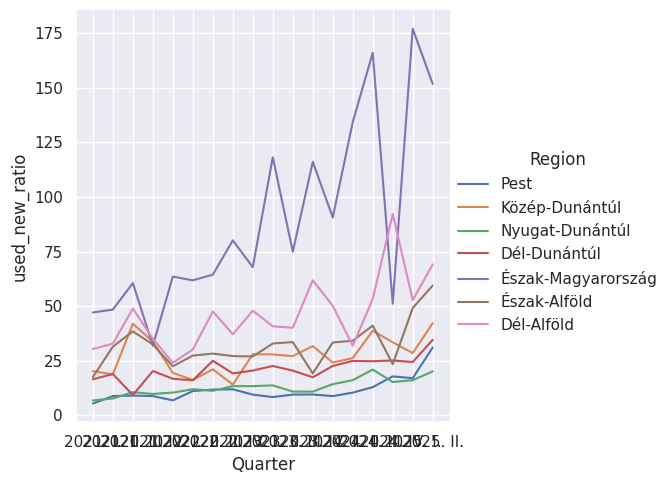

In [ ]:
sns.relplot(
    data=df_ratio, kind="line",
    x="Quarter", y="used_new_ratio",
    hue="Region", )



So, my answer to the question is that for some regions such as Eszak-Magyarorszag and Del Alfold, the the sales of used houses clearly outnumber the sales of new houses by a quite large margins. 175:1 used vs new ratio for one point in 2025, which is just incredible. Pest region shows consistent low numbers which makes somewhat of a sense given that Budapest is situated here.
```
[Q: How to make the x-axis more pretty? (perhaps with 
I | II | III | IV 
       2020
    )]
```

**Q2: In which region and at what time could one purchase how many square meters of a new apartment with a single
month's average net wage?**

In [34]:
df_long_re_prices["BuildingType"].unique()

<StringArray>
['single-family house, row house',                'multi-apartment',
                 'housing estate',                       'together',
                          'total']
Length: 5, dtype: string

In [23]:
# eguytt -> together (subtotal)
# osszesen -> total
prices_region_names = df_long_re_prices[df_long_re_prices['Type'] == "new"]["Region"].unique()
prices_region_names

<StringArray>
[          'Budapest',               'Pest',     'Közép-Dunántúl',
    'Nyugat-Dunántúl',       'Dél-Dunántúl', 'Észak-Magyarország',
       'Észak-Alföld',         'Dél-Alföld',             'Ország']
Length: 9, dtype: string

In [24]:
salary_region_names = df_net_salary_long[df_net_salary_long["RegionLevel"] == "region"]["RegionName"].unique()
salary_region_names

<StringArray>
[    'Közép-Dunántúl',    'Nyugat-Dunántúl',       'Dél-Dunántúl',
 'Észak-Magyarország',       'Észak-Alföld',         'Dél-Alföld']
Length: 6, dtype: string

In [28]:
# Is every item in a contained in b?
def is_contained(arr1, arr2):
    return set(arr1).issubset(set(arr2))
is_contained(salary_region_names ,prices_region_names)

True

What happened to Budapest and Pest and Orszag?

In [30]:
df_net_salary_long["RegionLevel"].unique()

<StringArray>
['capital city, region',       'county, region',         'large region',
               'county',               'region',              'country']
Length: 6, dtype: string

```
In RegionLevel:
capital city, region -> Budapest
county, region -> Pest
country -> Orszag összesen
```

In [77]:
# So we need to combine "capital city, region" and "county, region" records into "region"
region_like = ["region", "capital city, region", "county, region"]
df_salary_regions = df_net_salary_long[
    df_net_salary_long["RegionLevel"].isin(region_like)
]
df_salary_regions["RegionLevel"] = "region"

print(df_salary_regions["RegionLevel"].unique())   # ['region']
print(sorted(df_salary_regions["RegionName"].unique()))

# Need to rename RegionName column to Region after dropping the RegionLevel columns
df_salary_regions = df_salary_regions.drop(columns="RegionLevel").rename(
    columns={
        "RegionName": "Region"
        }
    )
df_salary_regions.head()

<StringArray>
['region']
Length: 1, dtype: str
['Budapest', 'Dél-Alföld', 'Dél-Dunántúl', 'Közép-Dunántúl', 'Nyugat-Dunántúl', 'Pest ', 'Észak-Alföld', 'Észak-Magyarország']


,Region,Quarter,NetWage(HUF)
0,Budapest,2018. I.,265035.0
1,Pest,2018. I.,190204.0
6,Közép-Dunántúl,2018. I.,199634.0
10,Nyugat-Dunántúl,2018. I.,196193.0
14,Dél-Dunántúl,2018. I.,178391.0


In [ ]:
df_new_together_prices = df_long_re_prices[
    (df_long_re_prices["Type"] == "new") &
    (df_long_re_prices["BuildingType"] == "together")
]
df_new_total_prices = df_long_re_prices[
    (df_long_re_prices["Type"] == "new") &
    (df_long_re_prices["BuildingType"] == "total")
]
# Drop implicit column
df_new_together_prices = df_new_together_prices.drop(columns="BuildingType")
df_new_together_prices['Region'].unique()

<StringArray>
[          'Budapest',               'Pest',     'Közép-Dunántúl',
    'Nyugat-Dunántúl',       'Dél-Dunántúl', 'Észak-Magyarország',
       'Észak-Alföld',         'Dél-Alföld']
Length: 8, dtype: string

At this point, the instructions were unclear about which one of `together` or `total` to take. I checked the data and there were 160 rows of together and few rows of total. and for total, the Region is always Orszag. So I'm thinking of proceeding with together df as we want regional stat not country level. 

In [66]:
df_new_together_prices.columns

Index(['Region', 'Quarter', 'PricePerSquareMeter(Thousand HUF)', 'Type'], dtype='str')

In [76]:
# Now we join df_new_together_prices with df_salary_regions on columns "Region" and "Quarter"
# Convert price is given in thousand HUF —  to HUF
df_new_together_prices["PricePerSquareMeter(HUF)"] = df_new_together_prices["PricePerSquareMeter(Thousand HUF)"] * 1000
df_new_prices = df_new_together_prices.drop(columns=["PricePerSquareMeter(Thousand HUF)", "Type"])
df_salary_price_ratio = df_new_prices.merge(df_salary_regions, on=["Region", "Quarter"], how="inner")
df_salary_price_ratio["NetWagePriceRatio"] = df_salary_price_ratio["NetWage(HUF)"] / df_salary_price_ratio["PricePerSquareMeter(HUF)"]
zero_price_row = df_salary_price_ratio["PricePerSquareMeter(HUF)"] == 0.0
# exclude the zero priced row from the data
df_salary_price_ratio = df_salary_price_ratio[~zero_price_row]
df_salary_price_ratio.head()
# df_new_together_prices.merge()

,Region,Quarter,PricePerSquareMeter(HUF),NetWage(HUF),NetWagePriceRatio
0,Budapest,2021. I.,852000.0,345910.0,0.405998
1,Közép-Dunántúl,2021. I.,569000.0,267241.0,0.469668
2,Nyugat-Dunántúl,2021. I.,490000.0,267173.0,0.545251
3,Dél-Dunántúl,2021. I.,702000.0,234796.0,0.334467
4,Észak-Magyarország,2021. I.,447000.0,226674.0,0.507101


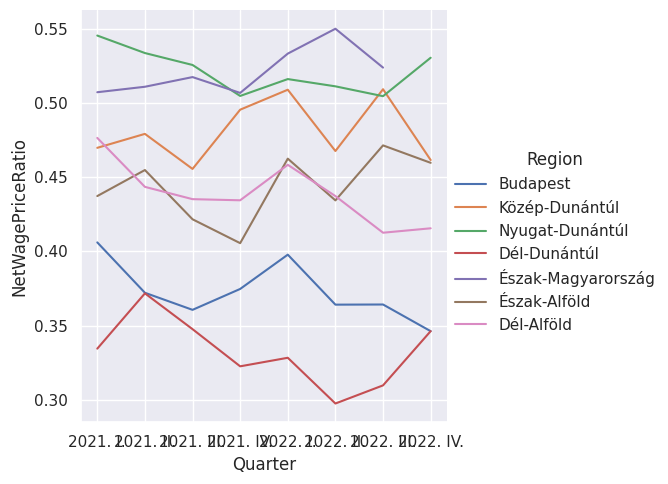

In [78]:
# Plot over time by region
sns.relplot(data=df_salary_price_ratio, kind="line",
    x="Quarter", y="NetWagePriceRatio",
    hue="Region",)

You can think that the best portion you can obtain of the house you want is 0.55 sqm per month in `Eszak-Magyarorszag` (I think it's a county literally named Northern Hungary where Miskolc is the main city). In other words, if you save up all your monthly wages in a year you would be able to get `0.55 * 12 ~= 6` sqm of a house.  Otherwise, in Budapest, you're having `0.4` sqm per month at best. But the data range became very narrow due to inconsistency in the data. Moreover, I don't know how realistic is the 0.55 sqm/month estimate.

I searched for an apartment at Miskolc and I found this posting for a moderate house:
![Ingatlan posting, Miskolc](assets/ingatlan.png)

I guess the NetWage is grossly underestimated. Surely people are having much higher wages than `226674.0` in Eszak-Magyarorszag right?

**Q3: How did the proportion of used versus new apartment sales change by region over time?**

**Q4: How did the price per square meter of a given apartment type change by region over time?**